<div class='arp'>
<h1> تسوية الهستوغرام :</h1>
<h2> الهدف: </h2>
</div>
<div class='arp'>
في هذا الفصل : سنتعلم مفهوم تسوية الهستوغرام ونستخدمه لتحسين تباين صورنا
</div>
<div class='arp'>
<h2> النظرية:</h2>
</div>
<div class='arp'>
فليكن لدينا صورة قيم بكسلاتها متجمعة في منطقة واحدة من الصورة . مثلاً الصور اللامعة قيم بكسلاتها متجمعة بالمناطق العالية القيم .  ولكن الصور الجيدة تمتلك توزعاً منتظما للقيم , ولذلك نحتاج لنشر تلك القيم على مجال اوسع . وهذا بالتالي يحسن تباين الصورة
</div>
<img src='https://upload.wikimedia.org/wikipedia/commons/c/ca/Histogrammeinebnung.png'>

<div class='arp'>

لتفاصيل اكثر , زر صفحة الموسوعة ويكيبيديا الخاصة بالموضوع . , حيث هناك شرح مفصل ( بالانكليزية) , اما هنا فسنعرض تطبيقOpenCV و Numpy بالتتالي , كما الكود التالي:

</div>

In [2]:
%matplotlib inline

import cv2
import numpy as np
from matplotlib import pyplot as plt

img = cv2.imread('wiki.jpg',0)

hist,bins = np.histogram(img.flatten(),256,[0,256])

cdf = hist.cumsum()
cdf_normalized = cdf * float(hist.max())/ cdf.max()


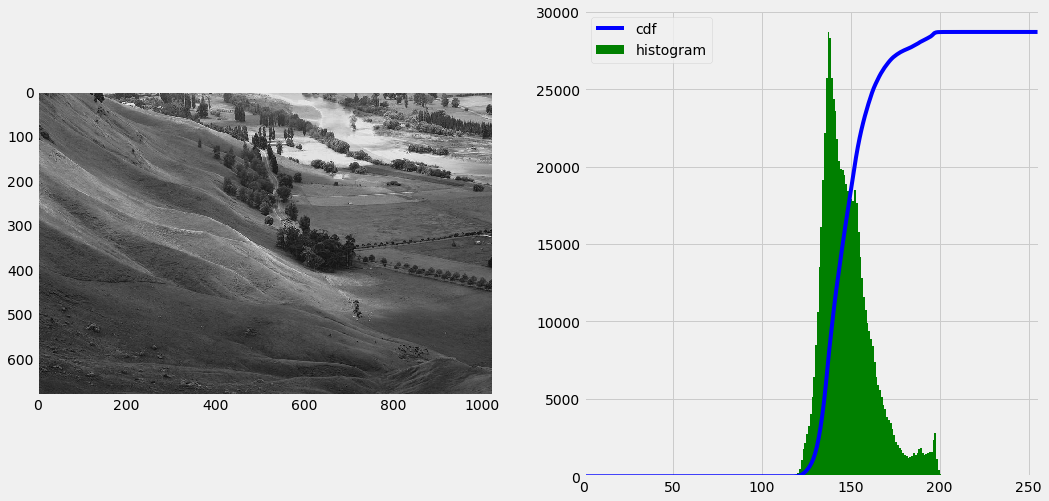

In [3]:
plt.style.use('fivethirtyeight')
plt.figure(figsize=(16,8))
plt.subplot(121)
plt.grid('off')
plt.imshow(img , cmap = 'gray')

plt.subplot(122)
plt.plot(cdf_normalized, color = 'b')
plt.hist(img.flatten(),256,[0,256], color = 'g')
plt.xlim([0,256])
plt.legend(('cdf','histogram'), loc = 'upper left')

plt.show()

 <div class='arp'>

 ولذلك نحتاج لانشاء تابع تحويل من الصورة الاولى للثانية , يدعى تسوية الهستوغرام.
 
 والان علينا البحث عن اخفض قيمة بعد الصفر للشدات لتطبيق علاقة التسوية , ولكن يمكن ايضاً استخدام مفهوم المصفوفات المقنعة في Numpy حيث تجرى العمليات فقط على العناصر غير المقنعة كالتالي:
 </div>

In [4]:
# hist op
cdf_m = np.ma.masked_equal(cdf,0)
cdf_m = (cdf_m - cdf_m.min())*255.0/(cdf_m.max()-cdf_m.min())
cdf = np.ma.filled(cdf_m,0).astype('uint8')

<div class='arp'>

وهنا اصبح لدينا الجدول البحثي للتحويل للصورة ويمكننا كنابة:
</div>

In [5]:
img2 = cdf[img]
cdf.shape

(256,)

<div class='arp'>

والان يمكننا حساب الهستوغرام والcdf  كما السابق والنتيجة كما التالي:
</div>

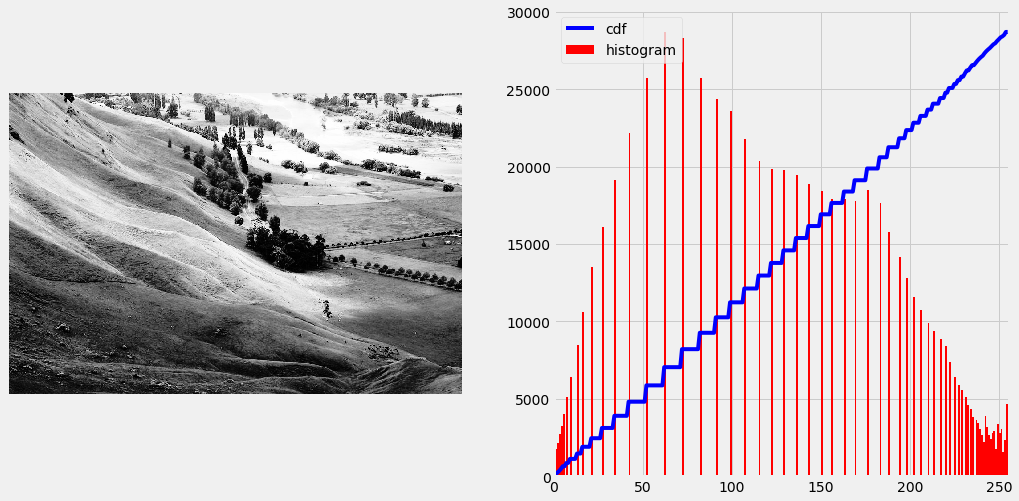

In [5]:
plt.figure(figsize=(16,8))
plt.subplot(121)
plt.grid('off')

plt.imshow(img2, cmap = 'gray')
plt.xticks([])
plt.yticks([])

hist,bins = np.histogram(img2.flatten(),256,[0,256])

cdf = hist.cumsum()
cdf_normalized = cdf * float(hist.max())/ cdf.max()

plt.subplot(122)
plt.plot(cdf_normalized, color = 'b')
plt.hist(img2.flatten(),256,[0,256], color = 'r')
plt.xlim([0,256])
plt.legend(('cdf','histogram'), loc = 'upper left')

plt.show()

<div class='arp'>

وهناك امر اخر , وهو انه حتى ولو كانت هذه الصور اغمق , فسنحصل في النهاية على نفس النتيجة , اي يمكن استخدام هذا كشروط اضاءة مرجعية , وهذا مفيد بعدة حالات , مثلاً حيث نريد اخذ عينات من صور الوجه للتعرف عليها فاننا نجعل كافة الصور ذات هستوغرام محسن اولاً..
</div>

<div class='arp'>
التالي يبين أداة تفاعلية , \لن تعمل في الا مع تشغيل الدفتر\ لتعديل الهستوغرام وملاحظة تغير تباين الصورة أثناء ذلك :)
</div>

In [1]:
import ipywidgets as widgets
L_slide = widgets.Layout(width='80%',height='3em')
L_button = widgets.Layout(width='20%',height='3em')

import IPython

img = cv2.imread('wiki.jpg',0)
hist,bins = np.histogram(img.flatten(),256,[0,256])
cdf0 = hist.cumsum()
cdf_normalized1 = cdf0 * float(hist.max())/ cdf.max()

def f1(x=10):
    # hist op
    IPython.display.clear_output()
    plt.clf()
    plt.figure(figsize=(9,9))
    cdf_m = (cdf0 )*255.0/(cdf0.max())
    cdf_m = np.ma.masked_outside(cdf_m,x.new[0],x.new[1])
    cdf_m = (cdf_m - cdf_m.min())*255.0/(cdf_m.max()-cdf_m.min())
    cdf = np.ma.filled(cdf_m,0).astype('uint8')
    img2 = cdf[img]
    hist2,bins = np.histogram(img2.flatten(),256,[0,255])

    cdf2 = hist.cumsum()
    cdf_normalized2 = cdf2 * float(hist.max())/ cdf2.max()
    plt.figure(1)
    plt.plot(cdf_normalized2, color = 'b')
    plt.hist(img2.flatten(),256,list(x.new), color = 'r')
    plt.xlim(list(x.new))
    plt.legend(('cdf','histogram'), loc = 'upper left')
    plt.show()

def f2(b):
    IPython.display.clear_output()
    plt.figure(figsize=(9,9))
    plt.grid('off')
    x = sld.value;
    cdf_m = (cdf0 )*255.0/(cdf0.max())
    cdf_m = np.ma.masked_outside(cdf_m,x[0],x[1])
    cdf_m = (cdf_m - cdf_m.min())*255.0/(cdf_m.max()-cdf_m.min())
    #print(cdf_m.shape)
    cdf = np.ma.filled(cdf_m,0).astype('uint8')
    img2 = cdf[img]
    plt.imshow(img2, cmap = 'gray')
    plt.xticks([])
    plt.yticks([])
    plt.show()


sld = widgets.IntRangeSlider(min=0,max=255,description='Expand range',continuous_update=False,
                        layout=L_slide);
sld.observe(f1,'value')
btn = widgets.Button(description='show image',layout=L_button,button_style='primary')
#(f1,'value')
inpts = [sld,
         btn]
btn.on_click(f2)
widgets.HBox(inpts)


NameError: name 'cv2' is not defined

In [8]:
btn.keys; 
cdf_m = np.ma.masked_inside(cdf0,10,100)
#f2()
#cdf_m

<div class='arh2'>

تسوية الهستوغرام في OpenCV:
</div>
<div class='arp'>

لدى OpenCV التابع التالي الذي يحسب الصورة المعدلة من الصورة الرمادية في الدخل **cv2.equalizeHist** 

والكود التالي يبين استخدامها :
</div>

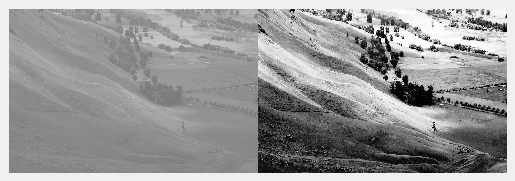

In [5]:
img = cv2.imread('wiki.jpg',0)
equ = cv2.equalizeHist(img)

res = np.hstack((img,equ)) #stacking images side-by-side

plt.figure(figsize=(8,4))
plt.imshow(res,cmap = 'gray')
plt.xticks([])
plt.yticks([])

plt.show()


<div class='arp'>

والان يمكنك اخذ عدة  صور مع اضاءات مختلفة وتعدلهم وتتحقق من النتيجة.
</div>
<div class='arp'>

وهذه الطريقة تعمل بشكل افضل عندما يكون توزع الشدات لبكسلات الصورة محصوراً بمنطقة معينة , ولكن ناتجها لن يكون بنفس الجودة من اجل الصور التي تختبر توزعاً عريضاً للبكسلات من الناحيتين المظلمةواللامعة..
</div>

<h2 class='arp'>
 CLAHE (تسوية الهستوغرام المتكيفة المحدودة التباين):
</h2>

<div class='arp'>
التعديل السابق للهستوغرام ياخذ بعين الاعتبار التباين الكلي للصورة , ولكن احياناً قد لا يصلح هذا , فالصورة التالية تظهر صورة الدخل وخرجها بعد تسوية الهستوغرام الشاملة:
</div>
<img src='http://docs.opencv.org/master/clahe_1.jpg'>

<div class='arp'>

الخلفية قد تكون تحسنت بالصورة السابقة ولكن ملامح الوجه تبدو زائلة بالمقارنة و هذا لان الهستوغرام غير مركز في منطقة واحدة كما سبق, 
</div>
<div class='arp'>

نحل هذه المشكلة باستخدام ** تسوية الهستوغرام المتكيفة** , وذلك يتم باخذ مكعبات (افتراضياً 8X8 )وتسوية الهستوغرام لكل منها على حدا , حيث نلاحظ ان هذا يأخذ بعين الاعتبار جزءاً من الصورة فقط وفي حالة وجود ضجيج يتم حذف اي قيمة لعمود من الهستوغرام الاصلي تتجاوز ال 40 افتراضياً ثم التسوية , واخيراً يتم اجراء استيفاء ثنائي الخطية على الحدود لتنعيم الانتقال , 
</div>
<div class='arp'>

التالي هو كود كمثال لتطبيق هذه الطريقة في OpenCV:
</div>

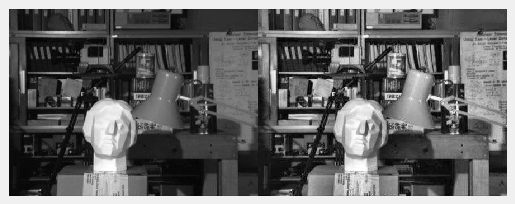

In [10]:
img = cv2.imread('tsukuba_l.png',0)

# create a CLAHE object (Arguments are optional).
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
cl1 = clahe.apply(img)

# interactive 
#from mpld3 import disable_notebook
#disable_notebook()

res = np.hstack([img,cl1])
plt.figure(figsize=(8,4))
plt.imshow(res ,cmap = 'gray')
plt.xticks([])
plt.yticks([])
plt.show()

<div class='arp'>

وكما نرى النتيجة , حيث تم تحاسين تفاصيل الوجه.
</div>

<h1 class='arp'>  الهستوغرام ثنائي الابعاد:</h1>

<h2 class='arp'> الهدف:</h2>
<div class='arp'>

سنتعلم هنا ايجاد ورسم الهستوغرام ثنائي الابعاد , وسيكون هذا جيداً للفصول القادمة .
</div>
<h2 class='arp'> مقدمة :</h2>
<div class='arp'>

في السابق , اوجدنا الهستوغرام احادي البعد , اما حالياً فسنبحث عن خاصيتين لرسمهما بشكل ثلاثي الابعاد , وعادة تكونان ال Heu & Saturation لكل بكسل .

هناك مثال يأتي مع تنصيب OpenCV  يتعلق بالرسم هكذا وبالتالي سنشرح المفهوم والذي سيفيد بعمليات اخرى مثل الاسقاط الخلفي للهستوغرام.
</div>
<h2 class='arp'> الهستوغرام 2D في OpenCV:</h2>
<div class='arp'>

هذا بسيط جداً , ويتم باستخدام نفس التابع , <strong>cv2.calcHist</strong> وللتحويل نحتاج لنقل الصورة لفضاء الالوان HSV  ,(سابقاً نقلناها للرمادي) والبارامترات كالتالي:
<ul>
<li> <strong>[0,1]=channels: </strong> لاننا نحتاج قناتين S و H.</li>

<li> <strong>[180,256]=bins: </strong> حيث 180 للمستوي H و 256 للمستوي S.</li>

<li> <strong>[0,180,0,256]=range: </strong>قيمة ال Hue  تستقر بين ال 0 وال 180 اما ال Saturation بين ال0 وال 256.</li>
</ul>
الان الى الكود:
</div>

In [7]:
img = cv2.imread('wt.jpg')
hsv = cv2.cvtColor(img,cv2.COLOR_BGR2HSV)

hist = cv2.calcHist([hsv],
                    [0, 1], None, [180, 256], [0, 180, 0, 256])

print hist.shape

(180, 256)


<h2 class='arp'> الهستوغرام 2D  في Numpy:</h2>
<div class='arp'>

ولدى Numpy تابع يقوم ايضاً بالحساب وهو **np.histogram2d** كالتالي:
</div>

In [8]:

h,s,v = hsv[:,:,0],hsv[:,:,1],hsv[:,:,2]

hist, xbins, ybins = np.histogram2d(
    h.ravel(),s.ravel(),[180,256],[[0,180],[0,256]])
print hist.shape

(180, 256)


<div class='arp'>
المتغير الاول هو المستويH  , المتغير الثاني هو المستوي S ,  الثالث هو عدد ال bins  والرابع مجالاتها..
</div>

<h2 class='arp'> رسم الهستوغرامات ال 2D:</h2>
<br>
<div class='arp'>
<ol>
<li> <strong>الطريقة الاولى : باستخدام cv2.imshow:</strong> بما ان النتيجة هي مصفوفة ثنائية فلذلك يمكن عرضها كصورة رمادية باستخدام التابع السابق , ولكن لن نحصل على فكرة كبيرة عن الالوان الا اذا كنا على علم بقيم ال Hue  للالوان المختلفة:</li>

<li> <strong>الطريقة الثانية : باستخدام Matplotlib : </strong> يمكننا استخدام الامر plt.imshow للرسم مع خرائط الوان مناسبوة وهذا سيعطينا فكرة افضل عن شدات البكسلات , ولكن يبقا أيضاً قاصراً عن العرض الكامل للمعلومات .</li>
</ol>
<br>
<strong> ملاحظة </strong> عند استخدام هذا التابع تذكر وضع العلم interpolation للقيمة nearest لنتائج افضل 

اعتبر الكود التالي:
</div>

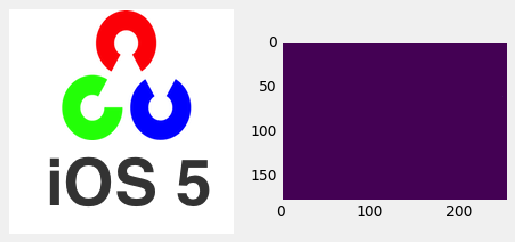

In [9]:
img = cv2.imread('opencv_ios.png')
# img = np.array([img[:,:,2],img[:,:,1],img[:,:,0]])

img = cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
hsv = cv2.cvtColor(img,cv2.COLOR_BGR2HSV)
hist = cv2.calcHist( [hsv],
                    [0, 1], None, [180, 256], [0, 180, 0, 256] )

plt.figure(figsize = (8,4))
plt.subplot(121)
plt.imshow(img,cmap = 'gray')
plt.xticks([])
plt.yticks([])

# plt.figure(figsize = (20,10))
plt.subplot(122)
plt.imshow(hist,interpolation = 'nearest')
plt.grid('off')
plt.show()

<div class='arp'>
وبذلك نلاحظ ان الصورة ربما ذات شدة متناسبة لذلك لا نحصل على معلومات كثيرة من رسم الهستوغرام , او ربما اختيارنا للصورة لم يكن موفقاً, 
<br>
<strong> الطريقة الثالثة : طريقة مثال OpenCV</strong> 
وهو كما المثال المرافق لمصدر OpenCV  , حيث يقوم باظهار الهستوغرام ثنائي البعد ويعطي , ويظهر اللون المرافق . , او بشكل مشفر .
<br>
وفي ذلك البرنامج يتم تحويل الصورة من BGR الى HSV ومن ثم يتم تحويل الهستوغرام الناتج حسب تابع التحويل نفسه , ومن ثم خطوات مسبقة لازالة البكسلات المعزولة والحصول على هستوغرام جيد , 
<br>
ويمكن العودة لذلك البرنامج , تشغيله , حيث ستلاحظ انه يعطي بالفعل الالوان الحقيقية تقريباُ الموجودة بالصورة..
<br>
</div>
<h2 class='arp'>
 مراجع اضافية
</h2>
<h2 class='arp'>
 تمارين
</h2>

<h1 class='arp'>
 الاسقاط الخلفي للهستوغرام:
</h1>
<h2 class='arp'>
 الهدف:
</h2>
<h2 class='arp'>
 النظرية:
 </h2>
<div class='arp'>
تم اقتراح التقنية السابقة من قبل Michael J. Swain , Dana H. Ballard بورقتهم , **الدلائل بوساطة الهستوغرامات الملونة **.
وتقوم على ايجاد الجسم المهم في الصورة من الخلفية بالتقطيع ,  حيث يتم الحصول على صورة خرج بنفس قياس صورة الدخل انما بطبقة واحدة ,وكل بكسل فيها يدلل على احتمال انتماءه للجسم المرغوب بشدته , وعليه ولعملية مثالية يكون الجسم ابيض والخلفية سوداء.
</div>
<div class='arp'>

ولتطبيقه , نوجد اولاً الهستوغرام , ومن ثم نحدد الصورة للجسم المراد اقتصاصه ويفضل ان يكون اكبر ما يكون نسبياً وكما يفضل ان يكون الهستوغرام ثنائي البعد وليس احادي , .. وبعد ذلك , نسقط الهستوغرام خلفياً على الصورة المختبرة , اي نحسب احتمال انتماء كل بكسل للخلفية , وبعدها وبعملية تعتيب نحصل على الخلفية لوحدها ( المبحوث عنها بحالتنا).
</div>

<h2 class='arp'>
الخورارزمية في Numpy:
</h2>

In [14]:
#roi is the object or region of object we need to find
roi = cv2.imread('orange.png')
hsv = cv2.cvtColor(roi,cv2.COLOR_BGR2HSV)

#target is the image we search in
target = cv2.imread('prblend.png')
hsvt = cv2.cvtColor(target,cv2.COLOR_BGR2HSV)

# Find the histograms using calcHist.
# Can be done with np.histogram2d also
M = cv2.calcHist([hsv],
                 [0, 1], None, [180, 256],
                 [0, 180, 0, 256] )
I = cv2.calcHist([hsvt],
                 [0, 1], None, [180, 256],
                 [0, 180, 0, 256] )

<div class='arp'>
<ol>
<li> اولا يجب حساب الهستوغرام الملون لكل من الجسم الذي نريد ايجاده , فليكن Mو والصورة التي نبحث فيها , ودعه  I. </li>

<li> اوجد النسبة $ R=\frac MI $ . ثم اسقط **R** خلفيا , باعتبارها اداة تلوين لانتاج صورة جديدة , كاحتماليتها المعتبرة بكونها هدفاً , اي  $$B(x,y) = R[h(x,y),s(x,y)]$$ حيث h و s هما قناتا اللون . وبعدها طبق الشرط
    $$ B(x,y)=min[B(x,y),1] $$ . </li>
</ol>
</div>

In [ ]:
h,s,v = cv2.split(hsvt)
R = M*np.invert(I)
B = R[h.ravel(),s.ravel()]
B = np.minimum(B,1)
B = B.reshape(hsvt.shape[:2])

<div class='arp'>
3.
 الان قم بالطي بقناع قرصي **B=BXD** , حيث D  هي قناع قرصي.

</div>

In [ ]:
disc = cv2.getStructuringElement(cv2.MORPH_ELLIPSE,(5,5))
cv2.filter2D(B,-1,disc,B)
B = np.uint8(B)
cv2.normalize(B,B,0,255,cv2.NORM_MINMAX)

<div class='arp'>

4. والان نحصل على مكان الجسم بوساطة المكان ذو الشدة الاكبر , ويمكننا بعد هذا القيام بالتعتيب بقيمة للحصول على نتائج افضل.
</div>

In [ ]:
ret,thresh = cv2.threshold(B,50,255,0)

تم الامر!!!

<h2 class='arp'>
 الاسقاط الخلفي في OpenCV:
</h2>
<br>
<div class='arp'>
لدى OpenCV تابع يدعى <strong>cv2.calcBackProject</strong> . بارامتراته تقريباً نفسها ل <strong>cv2.calcHist</strong> . احد بارامتراته هو هستوغرام الجسم المراد ايجاده ويجب تمريره معدلاً , ايضاً الخرج هو الصورة الاحتمالية وبالتالي يجب ايضاً طيها بقناع قرصي ويجب ايضاً تطبيق عتبة عليها , وفيما يلي مثال:
</div>

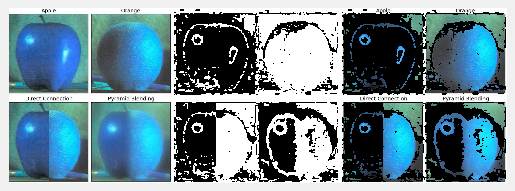

In [14]:
#roi is the object or region of object we need to find
roi = cv2.imread('orange.png')
hsv = cv2.cvtColor(roi,cv2.COLOR_BGR2HSV)

#target is the image we search in
target = cv2.imread('prblend.png')
hsvt = cv2.cvtColor(target,cv2.COLOR_BGR2HSV)

# calculating object histogram
roihist = cv2.calcHist([hsv],[0, 1],
                       None, [180, 256], [0, 180, 0, 256] )

# normalize histogram and apply backprojection
cv2.normalize(roihist,roihist,0,255,cv2.NORM_MINMAX)
dst = cv2.calcBackProject([hsvt],[0,1],roihist,[0,180,0,256],1)

# Now convolute with circular disc
disc = cv2.getStructuringElement(cv2.MORPH_ELLIPSE,(5,5))
cv2.filter2D(dst,-1,disc,dst)

# threshold and binary AND
ret,thresh = cv2.threshold(dst,50,255,0)
thresh = cv2.merge((thresh,thresh,thresh))
res = cv2.bitwise_and(target,thresh)

plt.figure(figsize = (8,4))
res = np.hstack((target,thresh,res))
plt.imshow(res)
plt.xticks([])
plt.yticks([])
plt.show()


<div class='arp'>

كما نلاحظ فان الناتج ,يوضح مكان البرتقالة بشكل اكبر بالصورة , ومكان نصف البرتقالة في باقي الصور..
</div>

<h2 class='arp'> مراجع اضافية:</h2>
<div class='arp'>

1. "التدليل من خلال هستوغرام الالوان" Swain, Michael J. , المؤتمر الرابع للرؤية الحاسوبية 1990.
</div>
<h2 class='arp'>
 تمارين </h2>